# Лабораторная работа № 4

# Бинарная классификация

**Цель работы:** познакомиться с применением модели машинного обучения для решения задачи классификации (метод логистической регрессии).

Проанализируем датасет onlinefoods. Датасет содержит информацию о покупателях и их предпочтениях в онлайн-заказах еды. Также он содержит информацию о том, оставил ли клиент положительный отзыв (Feedback). Смысл задачи — определять, основываясь на этих данных, будет ли отзыв положительным (Positive) или отрицательным (Negative). Набор данных включает следующие атрибуты:
- **Age** – возраст;
- **Gender** – пол (Female, Male, Prefer not to say);
- **Marital Status** – семейное положение;
- **Occupation** – род занятий;
- **Monthly Income** – ежемесячный доход;
- **Educational Qualifications** – уровень образования;
- **Family size** – размер семьи;
- **latitude** – широта;
- **longitude** – долгота;
- **Pin code** – почтовый индекс;
- **Output** – сделал ли заказ (Yes/No);
- **Feedback** – целевая переменная (Positive – положительный отзыв, Negative – отрицательный отзыв).

# 0. Импортируем библиотеки и загружаем данные

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Загружаем датасет через files.upload()
from google.colab import files

print("Пожалуйста, загрузите файл onlinefoods.csv")
uploaded = files.upload()

import io
df = pd.read_csv('onlinefoods.csv')

if 'Unnamed: 12' in df.columns:
    df = df.drop(columns=['Unnamed: 12'])

# Удаляем строки с пустым Feedback
df = df.dropna(subset=['Feedback'])

# Убираем лишние пробелы в строковых столбцах
string_columns = df.select_dtypes(include=['object']).columns
for col in string_columns:
    df[col] = df[col].str.strip()

df.head()

Пожалуйста, загрузите файл onlinefoods.csv


Saving onlinefoods.csv to onlinefoods (3).csv


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive


# 1. Извлечём последнюю строку датафрейма (практическое применение)

In [21]:
# Удаляем строку с индексом последней (последняя строка в датасете)
row_to_remove = df.iloc[-1]  # Берем последнюю строку
df = df.drop(df.index[-1])   # Удаляем последнюю строку

print("\nУдалённая строка (Series):")
print(row_to_remove)
print(f"Тип: {type(row_to_remove)}")


Удалённая строка (Series):
Age                                      23
Gender                                 Male
Marital Status                       Single
Occupation                          Student
Monthly Income                    No Income
Educational Qualifications    Post Graduate
Family size                               5
latitude                            12.8988
longitude                           77.5764
Pin code                             560078
Output                                  Yes
Feedback                           Positive
Name: 387, dtype: object
Тип: <class 'pandas.core.series.Series'>


# 2. Проанализируем значения целевой переменной

Выведем целевую переменную, уникальные значения и частоту каждого уникального значения:

In [22]:
(unique, counts) = np.unique(df['Feedback'], return_counts=True)
print('Unique values of the target variable: ', unique)
print('Counts of the target variable:', counts)

Unique values of the target variable:  ['Negative' 'Positive']
Counts of the target variable: [ 71 316]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную:

<Axes: xlabel='Feedback', ylabel='count'>

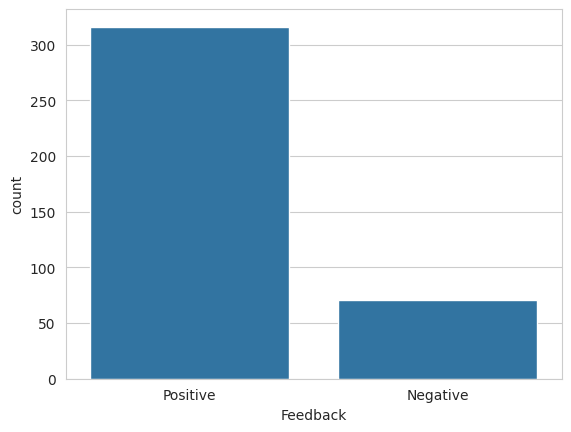

In [23]:
sns.set_style("whitegrid")
sns.countplot(df, x='Feedback')

> Диаграмма показывает, что набор данных является несбалансированным.
В датасете два класса: Positive (положительный отзыв) и Negative (отрицательный отзыв).

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         387 non-null    int64  
 1   Gender                      387 non-null    object 
 2   Marital Status              387 non-null    object 
 3   Occupation                  387 non-null    object 
 4   Monthly Income              387 non-null    object 
 5   Educational Qualifications  387 non-null    object 
 6   Family size                 387 non-null    int64  
 7   latitude                    387 non-null    float64
 8   longitude                   387 non-null    float64
 9   Pin code                    387 non-null    int64  
 10  Output                      387 non-null    object 
 11  Feedback                    387 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 36.4+ KB


> В нашем наборе данных два класса: Positive и Negative, что делает эту задачу задачей бинарной классификации.

# 3. Проверяем наличие пропущенных значений и выбросов

In [25]:
print(df.isnull().sum())

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
dtype: int64


> Пропущенные значения в датасете отсутствуют, обработка пропусков не требуется.

Проверим на наличие выбросов:

# 4. Исключаем невлияющие категориальные признаки

In [26]:
df_copy = df.copy()

# Исключаем признаки, которые не влияют на прогноз
cat_feat = ['latitude', 'longitude', 'Pin code']  # Географические данные не влияют на отзыв
df_copy.drop(columns=cat_feat, axis=1, inplace=True)

df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Yes,Positive


# 5. Заполняем пропущенные значения

Как было показано ранее, пропущенные значения в датасете отсутствуют. Заполнение пропусков не требуется.

# 6. Кодируем категориальные признаки

Все категориальные признаки в датасете нужно преобразовать в числовые.

In [27]:
binary_gender = { 'Female' : 1, 'Male' : 0, 'Prefer not to say' : 2}
df_copy['Gender'] = df_copy['Gender'].map(binary_gender)
df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,Single,Student,No Income,Post Graduate,4,Yes,Positive
1,24,1,Single,Student,Below Rs.10000,Graduate,3,Yes,Positive
2,22,0,Single,Student,Below Rs.10000,Post Graduate,3,Yes,Negative
3,22,1,Single,Student,No Income,Graduate,6,Yes,Positive
4,22,0,Single,Student,Below Rs.10000,Post Graduate,4,Yes,Positive


In [28]:
marital_status_map = {'Single': 0, 'Married': 1, 'Prefer not to say': 2}
df_copy['Marital Status'] = df_copy['Marital Status'].map(marital_status_map)
df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,0,Student,No Income,Post Graduate,4,Yes,Positive
1,24,1,0,Student,Below Rs.10000,Graduate,3,Yes,Positive
2,22,0,0,Student,Below Rs.10000,Post Graduate,3,Yes,Negative
3,22,1,0,Student,No Income,Graduate,6,Yes,Positive
4,22,0,0,Student,Below Rs.10000,Post Graduate,4,Yes,Positive


In [29]:
# Кодируем категориальный признак Occupation

from sklearn.preprocessing import LabelEncoder

# Создаем энкодер
encoder = LabelEncoder()

# Обучаем на всех данных
df_copy['Occupation'] = encoder.fit_transform(df_copy['Occupation'])
df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,0,3,No Income,Post Graduate,4,Yes,Positive
1,24,1,0,3,Below Rs.10000,Graduate,3,Yes,Positive
2,22,0,0,3,Below Rs.10000,Post Graduate,3,Yes,Negative
3,22,1,0,3,No Income,Graduate,6,Yes,Positive
4,22,0,0,3,Below Rs.10000,Post Graduate,4,Yes,Positive


In [30]:
# Кодируем категориальный признак Monthly Income

income_map = {
    'No Income': 0,
    'Below Rs.10000': 1,
    '10001 to 25000': 2,
    '25001 to 50000': 3,
    'More than 50000': 4
}
df_copy['Monthly Income'] = df_copy['Monthly Income'].map(income_map)
df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,0,3,0,Post Graduate,4,Yes,Positive
1,24,1,0,3,1,Graduate,3,Yes,Positive
2,22,0,0,3,1,Post Graduate,3,Yes,Negative
3,22,1,0,3,0,Graduate,6,Yes,Positive
4,22,0,0,3,1,Post Graduate,4,Yes,Positive


In [31]:
# Кодируем категориальный признак Educational Qualifications

edu_map = {
    'Uneducated': 0,
    'School': 1,
    'Graduate': 2,
    'Post Graduate': 3,
    'Ph.D': 4
}
df_copy['Educational Qualifications'] = df_copy['Educational Qualifications'].map(edu_map)
df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,0,3,0,3,4,Yes,Positive
1,24,1,0,3,1,2,3,Yes,Positive
2,22,0,0,3,1,3,3,Yes,Negative
3,22,1,0,3,0,2,6,Yes,Positive
4,22,0,0,3,1,3,4,Yes,Positive


In [32]:
# Кодируем категориальный признак Output

output_map = { 'Yes' : 1, 'No' : 0}
df_copy['Output'] = df_copy['Output'].map(output_map)

# Кодируем целевую переменную Feedback

feedback_map = { 'Positive' : 1, 'Negative' : 0}
df_copy['Feedback'] = df_copy['Feedback'].map(feedback_map)

df_copy.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
0,20,1,0,3,0,3,4,1,1
1,24,1,0,3,1,2,3,1,1
2,22,0,0,3,1,3,3,1,0
3,22,1,0,3,0,2,6,1,1
4,22,0,0,3,1,3,4,1,1


# 7. Разделяем данные на признаки и целевую переменную

In [33]:
y = df_copy['Feedback']
X = df_copy.drop('Feedback', axis=1)

X.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output
0,20,1,0,3,0,3,4,1
1,24,1,0,3,1,2,3,1
2,22,0,0,3,1,3,3,1
3,22,1,0,3,0,2,6,1
4,22,0,0,3,1,3,4,1


# 8. Разделяем данные на тренировочный и тестовый наборы

75% данных используется для обучения и 25% — для тестирования.

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# 9. Применяем операцию нормализации для численной устойчивости

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Обучаем модель логистической регрессии

In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

# 11. Делаем прогноз на основе данных тестирования

In [37]:
y_pred = model.predict(X_test_scaled)

# 12. Рассчитываем показатели точности, сравнив фактические и прогнозируемые значения

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print('True Positive(TP)  = ', TP)
print('False Positive(FP) = ', FP)
print('True Negative(TN)  = ', TN)
print('False Negative(FN) = ', FN)

accuracy =  (TP+TN) /(TP+FP+TN+FN)
print('Accuracy of the binary classification = {:0.3f}'.format(accuracy))

True Positive(TP)  =  78
False Positive(FP) =  4
True Negative(TN)  =  11
False Negative(FN) =  4
Accuracy of the binary classification = 0.918


In [39]:
# оцениваем точность модели
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9175257731958762


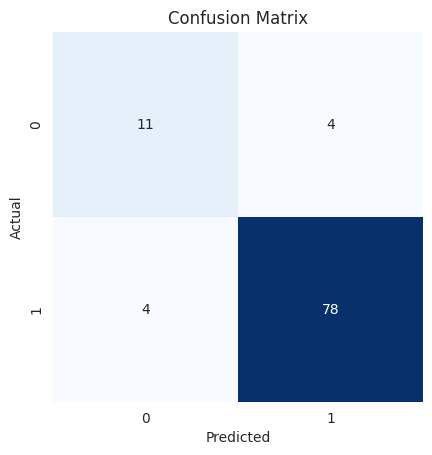

In [40]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

Точность: 0.92
Точность: 0.95
Полнота: 0.95
F1-мера: 0.95


# 13. Корреляционная матрица

In [42]:
df_copy.corr()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Output,Feedback
Age,1.000000,-0.063349,0.615545,-0.578899,0.561723,-0.099147,0.172214,-0.247479,-0.197633
Gender,-0.063349,1.000000,0.023203,0.006793,-0.132968,0.076296,0.085597,-0.033545,0.046602
Marital Status,0.615545,0.023203,1.000000,-0.540077,0.538901,-0.108278,0.130652,-0.281179,-0.209235
Occupation,-0.578899,0.006793,-0.540077,1.000000,-0.727259,0.115858,-0.059462,0.252675,0.195202
Monthly Income,0.561723,-0.132968,0.538901,-0.727259,1.000000,-0.026301,0.081246,-0.221347,-0.157140
Educational Qualifications,-0.099147,0.076296,-0.108278,0.115858,-0.026301,1.000000,-0.053975,0.078703,0.120345
Family size,0.172214,0.085597,0.130652,-0.059462,0.081246,-0.053975,1.000000,-0.045663,-0.011734
Output,-0.247479,-0.033545,-0.281179,0.252675,-0.221347,0.078703,-0.045663,1.000000,0.592345
Feedback,-0.197633,0.046602,-0.209235,0.195202,-0.157140,0.120345,-0.011734,0.592345,1.000000


# 14. Строим ROC-кривую

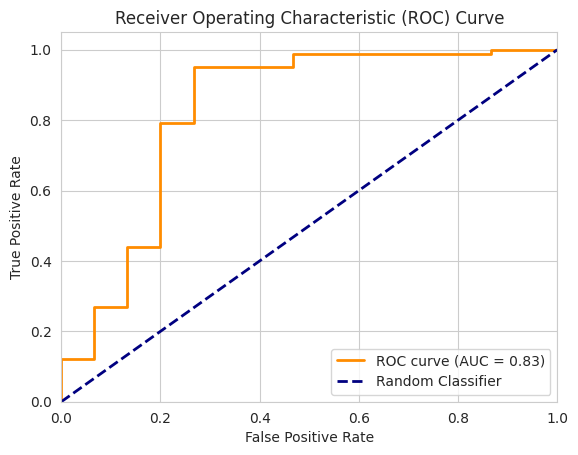

In [43]:
from sklearn.metrics import roc_curve, auc
y_score = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 15. Подготовка новых данных для прогноза

In [46]:
# 15. Подготовка новых данных для прогноза

# Допустим, у нас есть еще один клиент
new_data = pd.DataFrame({
    'Age': [row_to_remove['Age']],
    'Gender': [row_to_remove['Gender']],
    'Marital Status': [row_to_remove['Marital Status']],
    'Occupation': [row_to_remove['Occupation']],
    'Monthly Income': [row_to_remove['Monthly Income']],
    'Educational Qualifications': [row_to_remove['Educational Qualifications']],
    'Family size': [row_to_remove['Family size']],
    'Output': [row_to_remove['Output']]
})

print("Данные до кодирования:")
print(new_data)

# Кодируем новые данные (важно: использовать те же маппинги, что и для тренировочных данных)
new_data['Gender'] = new_data['Gender'].map(binary_gender)
new_data['Marital Status'] = new_data['Marital Status'].map(marital_status_map)
new_data['Occupation'] = encoder.transform(new_data['Occupation'])
new_data['Monthly Income'] = new_data['Monthly Income'].map(income_map)
new_data['Educational Qualifications'] = new_data['Educational Qualifications'].map(edu_map)
new_data['Output'] = new_data['Output'].map(output_map)

print("\nДанные после кодирования (числовые):")
print(new_data)

new_data_scaled = scaler.transform(new_data)

print("\nДанные после нормализации:")
print(new_data_scaled)

Данные до кодирования:
   Age Gender Marital Status Occupation Monthly Income  \
0   23   Male         Single    Student      No Income   

  Educational Qualifications  Family size Output  
0              Post Graduate            5    Yes  

Данные после кодирования (числовые):
   Age  Gender  Marital Status  Occupation  Monthly Income  \
0   23       0               0           3               0   

   Educational Qualifications  Family size  Output  
0                           3            5       1  

Данные после нормализации:
[[-0.53915042 -0.82237496 -0.63988083  0.83629392 -0.93654621  0.66482551
   1.25541954  0.55876399]]


# 16. Делаем прогноз

In [47]:
# Предсказываем класс (0 или 1)
predicted_class = model.predict(new_data_scaled)
print(f"Предсказанный класс: {predicted_class[0]}")

# Предсказываем вероятность (гораздо информативнее!)
predicted_proba = model.predict_proba(new_data_scaled)
print(f"Вероятности для классов [0, 1]: {predicted_proba[0]}")

# Можно красиво оформить
probability_of_positive_class = predicted_proba[0][1]
print(f"Вероятность положительного исхода: {probability_of_positive_class:.2f}")

Предсказанный класс: 1
Вероятности для классов [0, 1]: [0.05143918 0.94856082]
Вероятность положительного исхода: 0.95


# 17. Исследовательский анализ данных (EDA)

In [48]:
# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

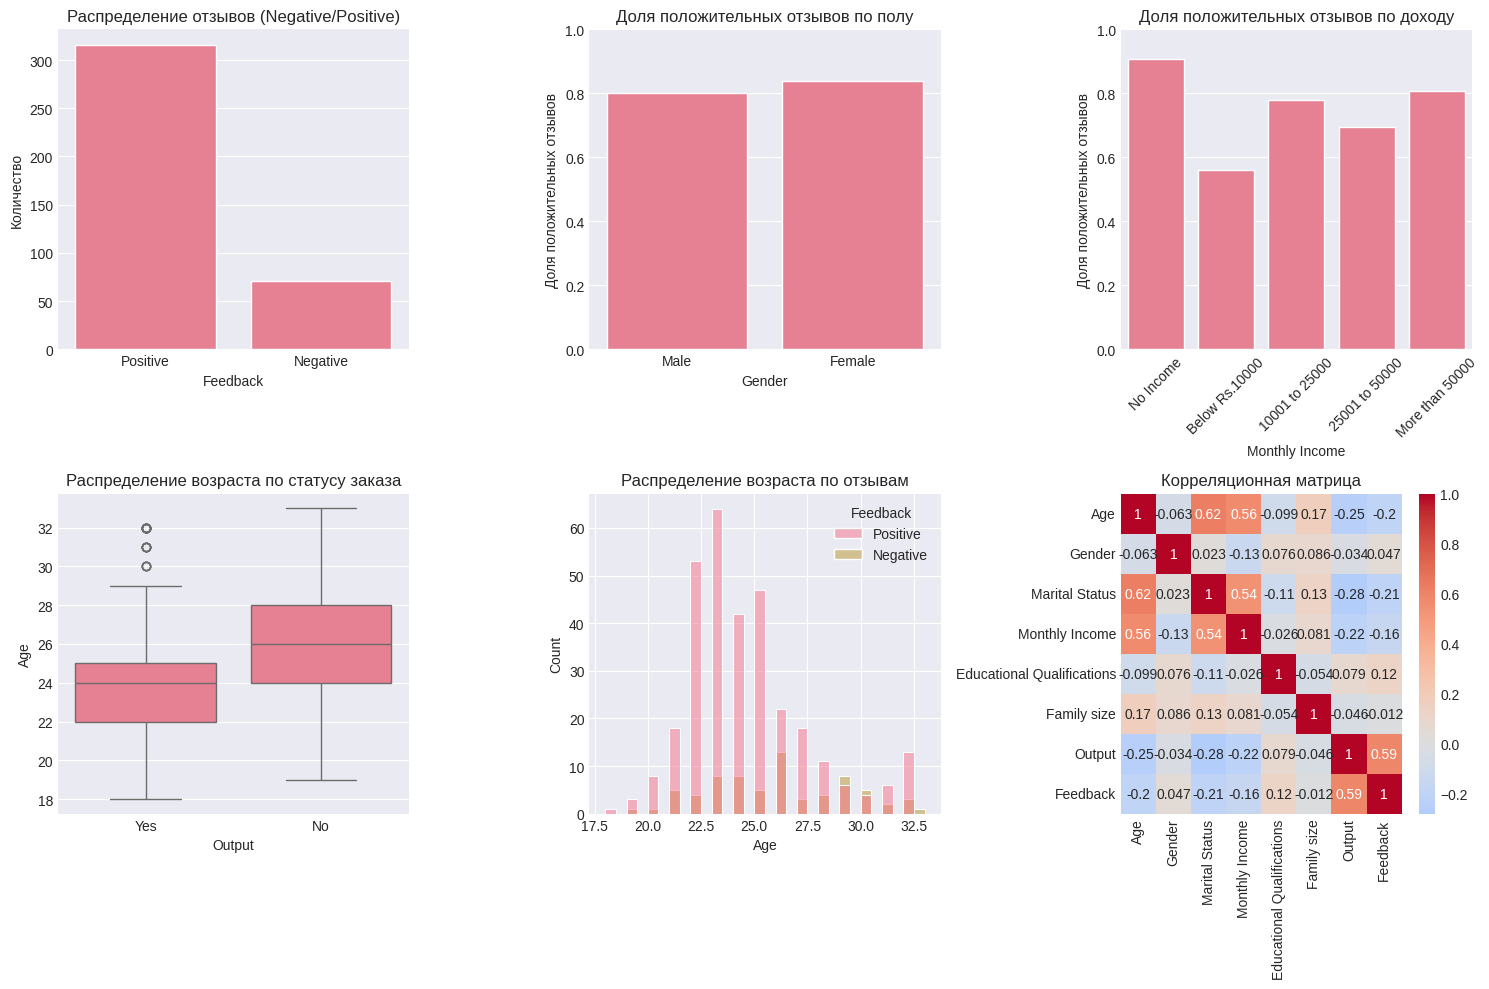

In [52]:
# Визуализация отзывов
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Целевая переменная (используем df с исходными названиями)
sns.countplot(data=df, x='Feedback', ax=axes[0, 0])
axes[0, 0].set_title('Распределение отзывов (Negative/Positive)')
axes[0, 0].set_xlabel('Feedback')
axes[0, 0].set_ylabel('Количество')

# 2. Доля положительных отзывов по полу (используем df_copy с числовыми значениями)
# Создаем временный датафрейм для агрегации
gender_feedback = df_copy.groupby('Gender')['Feedback'].mean().reset_index()
gender_feedback['Gender'] = gender_feedback['Gender'].map({1: 'Female', 0: 'Male', 2: 'Prefer not to say'})
sns.barplot(data=gender_feedback, x='Gender', y='Feedback', ax=axes[0, 1])
axes[0, 1].set_title('Доля положительных отзывов по полу')
axes[0, 1].set_ylabel('Доля положительных отзывов')
axes[0, 1].set_ylim(0, 1)

# 3. Доля положительных отзывов по доходу (используем df_copy с числовыми значениями)
income_feedback = df_copy.groupby('Monthly Income')['Feedback'].mean().reset_index()
income_map_reverse = {0: 'No Income', 1: 'Below Rs.10000', 2: '10001 to 25000',
                       3: '25001 to 50000', 4: 'More than 50000'}
income_feedback['Monthly Income'] = income_feedback['Monthly Income'].map(income_map_reverse)
sns.barplot(data=income_feedback, x='Monthly Income', y='Feedback', ax=axes[0, 2])
axes[0, 2].set_title('Доля положительных отзывов по доходу')
axes[0, 2].set_ylabel('Доля положительных отзывов')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].set_ylim(0, 1)

# 4. Распределение возраста по статусу заказа
sns.boxplot(data=df, x='Output', y='Age', ax=axes[1, 0])
axes[1, 0].set_title('Распределение возраста по статусу заказа')

# 5. Распределение возраста по отзывам
sns.histplot(data=df, x='Age', hue='Feedback', bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Распределение возраста по отзывам')

# 6. Тепловая карта корреляций (используем df_copy с числовыми значениями)
numeric_cols = ['Age', 'Gender', 'Marital Status', 'Monthly Income',
                'Educational Qualifications', 'Family size', 'Output', 'Feedback']
corr_matrix_eda = df_copy[numeric_cols].corr()
sns.heatmap(corr_matrix_eda, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

> Анализ графиков показывает следующее: набор данных содержит больше положительных отзывов (класс Positive), чем отрицательных (класс Negative). Женщины (Female) оставляют положительные отзывы чаще мужчин (Male). Люди без дохода оставляют положительные отзывы намного чаще чем остальные люди с разными уровнями дохода. Распределение возраста по статусу заказа показывает, что клиенты, сделавшие заказ, в среднем моложе. Распределение возраста по отзывам показывает, что молодые люди чаще оставляют положительные отзывы. Корреляционная матрица подтверждает, что наибольшую связь с отзывом имеют Output (0.59).